# Анализ русскоязычных НПА Казахстана: недели 1–4
Учебный, воспроизводимый разбор. НПА — нормативный правовой акт. Исходные страницы шести актов сохранены в `data/raw`, поэтому повторный запуск анализа не требует интернета. Источники и время загрузки перечислены в `data/processed/corpus_summary.json`. Подробные выводы — в `docs/coursework_weeks_1_4.md`.

In [2]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from lawankz.corpus import load_documents
from lawankz.coursework import prepare_articles, preprocess_text, run_analysis

DATA = ROOT / 'data' / 'processed'
OUT = ROOT / 'results' / 'weeks_1_4'
print('Проект:', ROOT)

Проект: c:\Users\danil\Documents\AIU\Обработка языков\LawanKZ


## Неделя 1 — корпус и статистика
Единица исходного корпуса — целый акт. Для матриц ниже единица наблюдения — статья: иначе было бы всего 6 строк. Шесть актов вместе превышают альтернативный порог задания в 50 000 слов.

In [3]:
documents = load_documents(DATA / 'documents.jsonl')
corpus_stats = pd.DataFrame([
    {'Акт': d['title'], 'Слов': d['word_count'], 'Источник': d['url']}
    for d in documents
])
display(corpus_stats)
print('Актов:', len(documents), '| слов:', corpus_stats['Слов'].sum())
assert corpus_stats['Слов'].sum() >= 50_000

,Акт,Слов,Источник
0,О персональных данных и их защите,7723,https://old.adilet.zan.kz/rus/docs/Z1300000094
1,О кибербезопасности,11568,https://old.adilet.zan.kz/rus/docs/Z1500000418
2,Цифровой кодекс Республики Казахстан,13616,https://old.adilet.zan.kz/rus/docs/K2600000255
3,О связи,18078,https://old.adilet.zan.kz/rus/docs/Z040000567_
4,О доступе к информации,8149,https://old.adilet.zan.kz/rus/docs/Z1500000401
5,Об искусственном интеллекте,3333,https://old.adilet.zan.kz/rus/docs/Z2500000230


Актов: 6 | слов: 62467


## Неделя 2 — очистка текста
`preprocess_text` разбивает текст на токены, приводит слова к нижнему регистру, удаляет пунктуацию, числа и большинство стоп-слов. Юридически значимые `не`, `без`, `должен`, `данные` сохранены. Ниже одно и то же предложение до и после обработки.

In [3]:
example = 'Оператор не должен передавать персональные данные без согласия субъекта.'
processed = preprocess_text(example)
print('До:    ', example)
print('Слова: ', ' '.join(processed['words']))
print('Леммы: ', ' '.join(processed['lemmas']))
print('Стемы: ', ' '.join(processed['stems']))
articles = prepare_articles(documents)
print('Статей-кандидатов:', len(articles))

До:     Оператор не должен передавать персональные данные без согласия субъекта.
Слова:  оператор не должен передавать персональные данные без согласия субъекта
Леммы:  оператор не должный передавать персональный данные без согласие субъект
Стемы:  оператор не долж передава персональн дан без соглас субъект
Статей-кандидатов: 325


## Пересчёт результатов
Следующая ячейка выполняет обработку всех статей, сохраняет таблицы, матрицы и рисунки. После неё остальные ячейки читают эти файлы. Обработка может занять несколько минут.

In [4]:
summary = run_analysis(documents, OUT)
display(pd.DataFrame([
    {'Показатель': 'Исходных слов', 'Значение': summary['raw_word_count']},
    {'Показатель': 'Статей в матрицах', 'Значение': summary['article_count']},
    {'Показатель': 'Токенов до очистки', 'Значение': summary['tokens_before_cleaning']},
    {'Показатель': 'Токенов после очистки', 'Значение': summary['tokens_after_cleaning']},
    {'Показатель': 'Уникальных словоформ', 'Значение': summary['unique_words']},
    {'Показатель': 'Уникальных лемм', 'Значение': summary['unique_lemmas']},
]))

,Показатель,Значение
0,Исходных слов,62467
1,Статей в матрицах,325
2,Токенов до очистки,60004
3,Токенов после очистки,45924
4,Уникальных словоформ,6374
5,Уникальных лемм,2838


## Неделя 3 — морфология, леммы и стемы
Лемма — словарная форма (`информации → информация`). Стем — грубо усечённая основа (`информации → информац`). POS обозначает часть речи; Case — падеж; Number — число. Прочерк значит, что признак к токену не применим или модель его не определила.

In [5]:
display(pd.read_csv(OUT / 'top50_words.csv').head(50))
display(pd.read_csv(OUT / 'top50_lemmas.csv').head(50))
comparison = pd.read_csv(OUT / 'lemma_vs_stem.csv')
display(comparison[['word', 'lemma_spacy', 'stem_snowball', 'pos', 'case', 'number', 'frequency']].head(20))
display(pd.read_csv(OUT / 'morphology.csv').head(15))

,word,frequency
0,казахстан,982
1,республики,942
2,связи,846
3,цифровых,510
4,информации,352
5,кибербезопасности,350
6,цифровой,336
7,персональных,317
8,проверки,311
9,соответствии,303


,lemma,frequency
0,цифровой,1369
1,казахстан,983
2,республика,982
3,связь,876
4,орган,785
5,государственный,675
6,объект,553
7,лицо,519
8,информация,493
9,проверка,396


,word,lemma_spacy,stem_snowball,pos,case,number,frequency
0,казахстан,казахстан,казахста,PROPN,Nom,Sing,982
1,республики,республика,республик,PROPN,Gen,Sing,942
2,связи,связь,связ,NOUN,Gen,Sing,838
3,цифровых,цифровой,цифров,ADJ,Gen,Plur,458
4,кибербезопасности,кибербезопасности,кибербезопасн,NOUN,Gen,Sing,333
5,соответствии,соответствие,соответств,NOUN,Loc,Sing,303
6,проверки,проверка,проверк,NOUN,Gen,Sing,299
7,персональных,персональный,персональн,ADJ,Gen,Plur,283
8,цифрового,цифровой,цифров,ADJ,Gen,Sing,272
9,не,не,не,PART,—,—,261


,pos,case,number,frequency
0,NOUN,Gen,Sing,9690
1,NOUN,Gen,Plur,4250
2,ADJ,Gen,Sing,3122
3,ADJ,Gen,Plur,2654
4,NOUN,Nom,Sing,2575
5,NOUN,Loc,Sing,2543
6,NOUN,Acc,Sing,2350
7,NOUN,Ins,Sing,1481
8,VERB,—,Sing,1177
9,PROPN,Gen,Sing,1156


## Неделя 4 — BoW и TF‑IDF
BoW — число вхождений леммы в статью. TF‑IDF увеличивает вес лемм, характерных для некоторых статей, и уменьшает вес встречающихся почти всюду. Обе матрицы имеют одинаковые строки (статьи) и столбцы (леммы). Для словаря используются `min_df=2` и `max_df=0.95`; TF‑IDF в scikit-learn нормирован по L2. Глобальный средний TF‑IDF — описательная статистика, а не доказательство юридической важности слова.

In [6]:
from scipy.sparse import load_npz
bow = load_npz(OUT / 'bow_matrix.npz')
tfidf = load_npz(OUT / 'tfidf_matrix.npz')
index = pd.read_csv(OUT / 'article_index.csv')
vocab = pd.read_csv(OUT / 'vocabulary.csv')
print('BoW:', bow.shape, '| TF-IDF:', tfidf.shape)
assert bow.shape == tfidf.shape == (len(index), len(vocab))
display(pd.read_csv(OUT / 'top50_bow.csv'))
display(pd.read_csv(OUT / 'top50_tfidf.csv'))

BoW: (325, 1718) | TF-IDF: (325, 1718)


,term,score
0,цифровой,1369
1,казахстан,983
2,республика,982
3,связь,876
4,орган,785
5,государственный,675
6,объект,553
7,лицо,519
8,информация,493
9,проверка,396


,term,score
0,цифровой,0.121473
1,казахстан,0.071496
2,республика,0.071417
3,связь,0.063533
4,объект,0.055684
5,государственный,0.054095
6,персональный,0.050425
7,орган,0.046286
8,кибербезопасности,0.045964
9,закон,0.040832


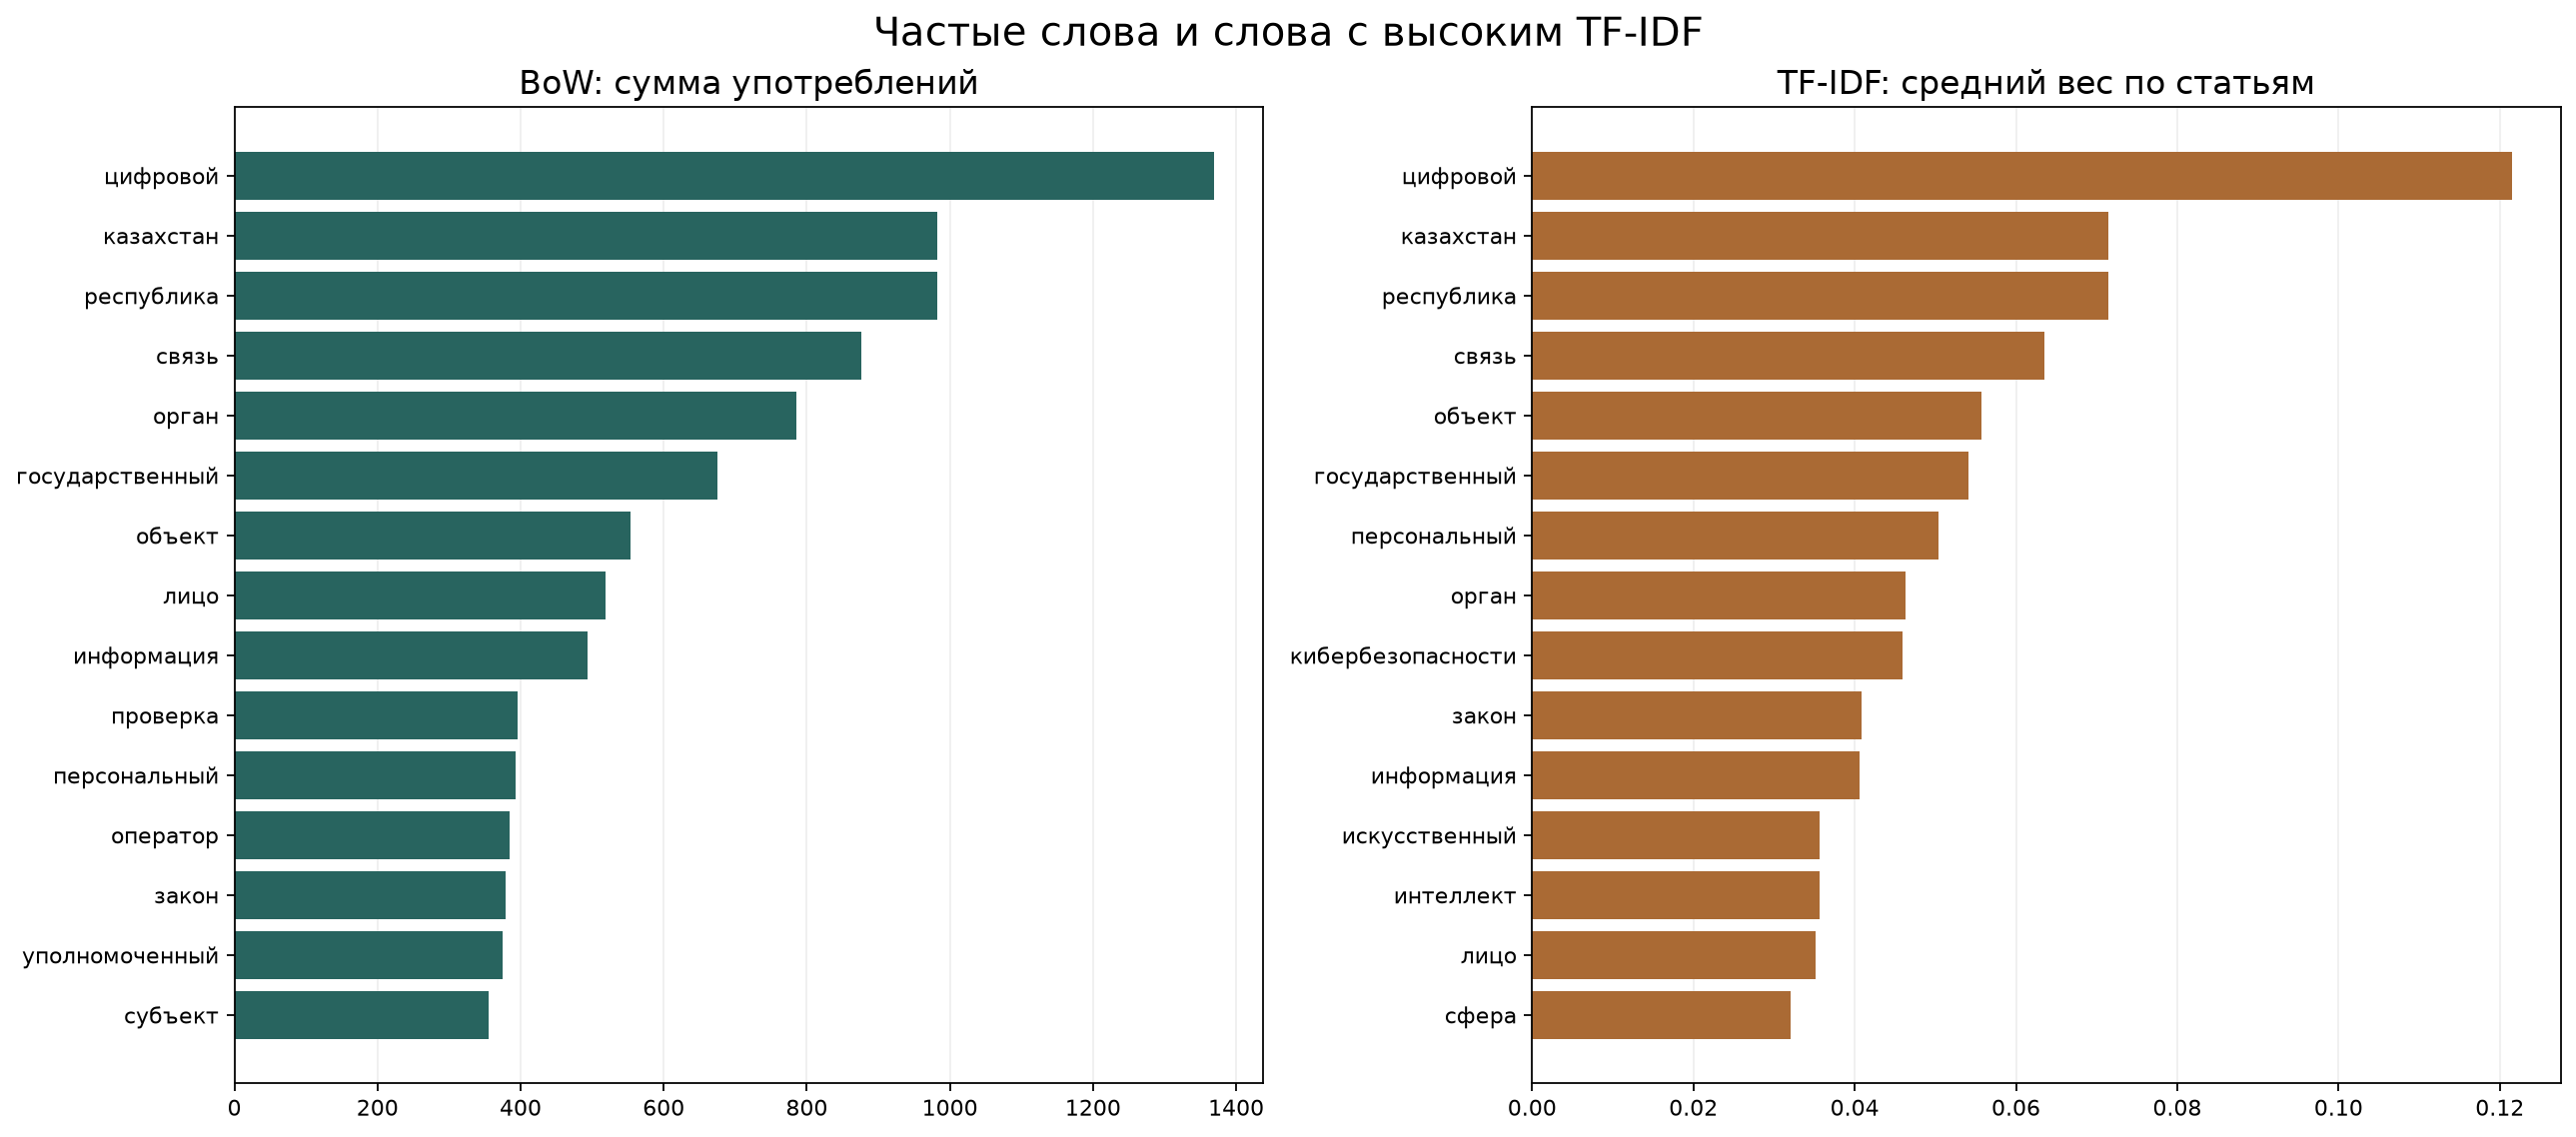

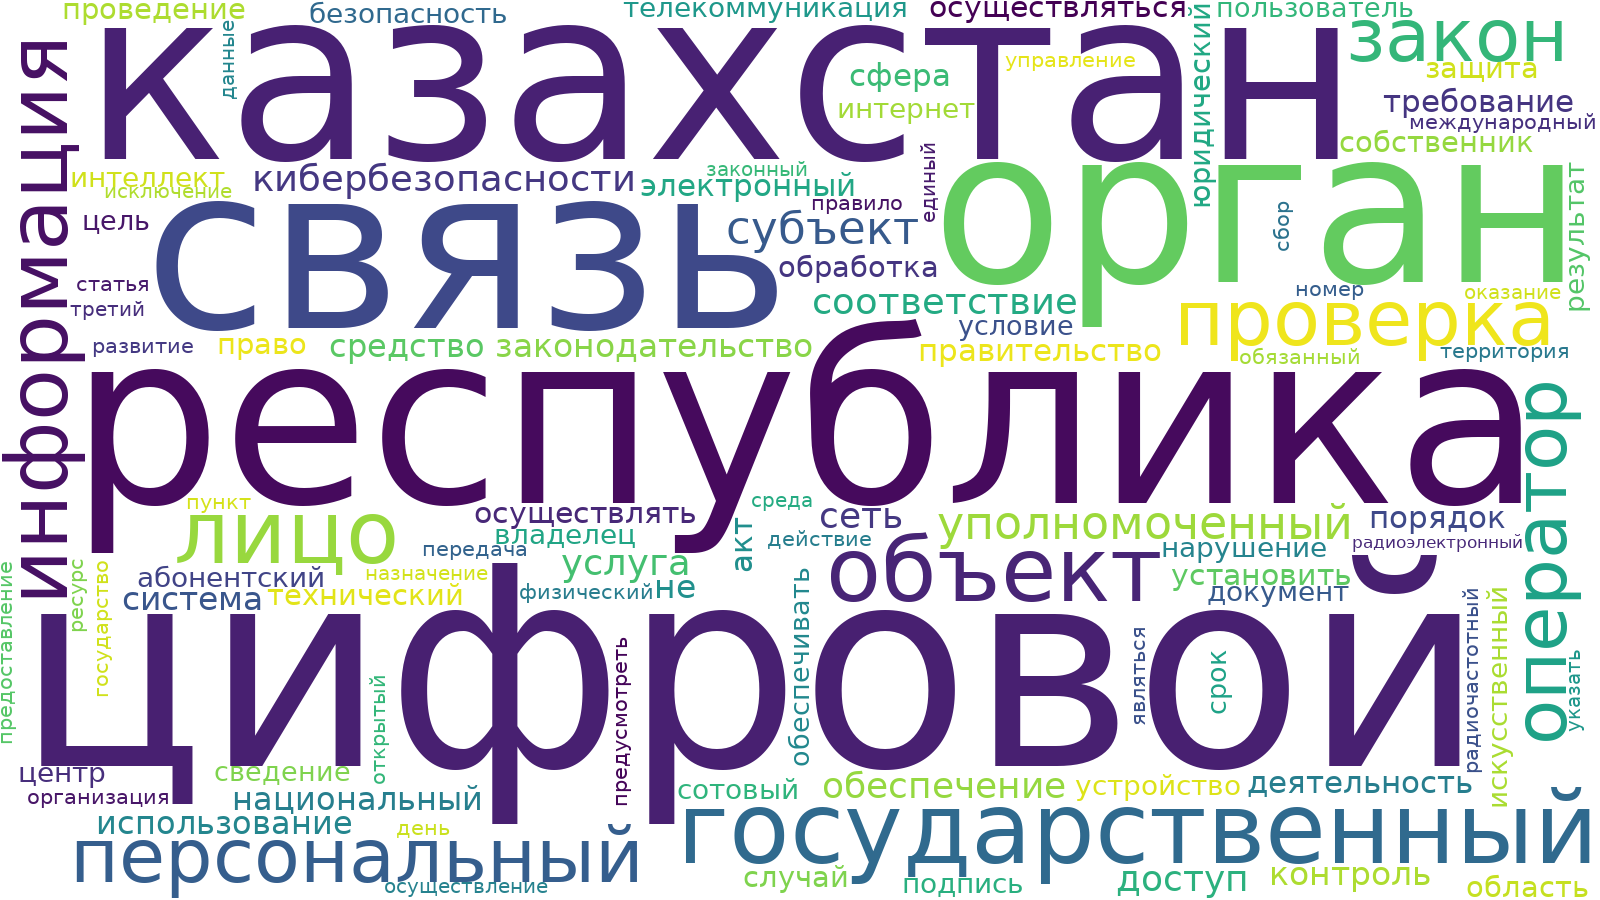

In [7]:
display(Image(filename=str(OUT / 'bow_vs_tfidf.png')))
display(Image(filename=str(OUT / 'wordcloud_lemmas.png')))

In [8]:
distinctive = pd.read_csv(OUT / 'distinctive_terms_by_document.csv')
display(distinctive.groupby('document_id', sort=False).head(5).reset_index(drop=True))
print('Это контраст средних TF-IDF внутри акта и в остальных актах, а не правовая экспертиза.')

,document_id,term,own_mean_tfidf,other_mean_tfidf,difference
0,access_to_information,информация,0.330702,0.014337,0.316365
1,access_to_information,обладатель,0.112978,0.000193,0.112785
2,access_to_information,доступ,0.124051,0.020019,0.104032
3,access_to_information,запрос,0.051549,0.003854,0.047695
4,access_to_information,размещение,0.044372,0.005459,0.038913
5,artificial_intelligence,искусственный,0.350658,0.002401,0.348257
6,artificial_intelligence,интеллект,0.350658,0.002401,0.348257
7,artificial_intelligence,система,0.150768,0.017501,0.133268
8,artificial_intelligence,библиотека,0.038624,0.000341,0.038283
9,artificial_intelligence,риск,0.039762,0.003123,0.036639


Это контраст средних TF-IDF внутри акта и в остальных актах, а не правовая экспертиза.


### Ограничения
Это небольшой тематический корпус: частотности зависят от выбора шести актов и длины их статей. Выгрузки фиксируют состояние источников на дату скачивания, а не гарантируют актуальность нормы в будущем. spaCy иногда ошибается на юридических терминах; результаты требуют ручной проверки. Собственные выводы студента стоит добавить после просмотра нескольких статей и таблиц.